In [1]:
from mmpretrain.registry import MODELS
import torch

[2025-08-11 12:51:34,058] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/tmp/tmplqh3e2v6/test.o: In function `main':
test.c:(.text.startup+0x5): undefined reference to `io_pgetevents'
collect2: error: ld returned 1 exit status


 [WARNING]  async_io requires the dev libaio .so object and headers but these were not found.
 [WARNING]  If libaio is already installed (perhaps from source), try setting the CFLAGS and LDFLAGS environment variables to where it can be found.
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  sparse_attn requires a torch version >= 1.5 and < 2.0 but detected 2.3
 [WARNING]  using untested triton version (2.3.1), only 1.0.0 is known to be compatible


In [10]:

MODELS.get('HCSChannelViT')
model = MODELS.build(dict(
    type='HCSChannelViT',
    img_size=[224],
    in_chans=8, # max channels of dataset
    embed_dim=768,

))


Warning!!!
Samplev2 channel vit randomly sample channels for each batch.
It is only compatible with Supervised learning
Doesn't work with DINO or Linear Prob


In [13]:

bs = 2
dummy_input = torch.randn(bs, 5, 224, 224)
channels = [0, 1, 2, 3, 4]
channels = torch.tensor([c for c in channels])
channels = channels.unsqueeze(0).repeat(bs, 1)
channels.shape, channels

(torch.Size([2, 5]),
 tensor([[0, 1, 2, 3, 4],
         [0, 1, 2, 3, 4]]))

In [14]:
extra = {"channels": channels}

out = model(dummy_input, extra)

In [15]:
out[0].shape

torch.Size([2, 768])

# cloudsen12 process

In [1]:
import os
from osgeo import gdal
import numpy as np

In [18]:


ROOT = r"/mnt/CLOUD/data/cloudsen12/geotiffs"   # ← 改成你的根目录（含各 ROI_* 子目录）
# ROOT = r"/mnt/CLOUD/data/cloudsen12/geotiff_test"   # ← 改成你的根目录（含各 ROI_* 子目录）
TARGET_NAME = "target.tif"  # 如有变化在这改
VALUE = 99                  # 要查找的像元值

In [3]:


def has_value_99(tif_path, value=VALUE):
    ds = gdal.Open(tif_path, gdal.GA_ReadOnly)
    if ds is None:
        return False
    band = ds.GetRasterBand(1)  # 假定单通道语义标签
    xsize, ysize = ds.RasterXSize, ds.RasterYSize

    # 以块大小遍历，内存友好
    bx, by = band.GetBlockSize()
    if bx == 0 or by == 0:
        bx, by = 512, 512  # 兜底

    for y in range(0, ysize, by):
        h = min(by, ysize - y)
        for x in range(0, xsize, bx):
            w = min(bx, xsize - x)
            arr = band.ReadAsArray(x, y, w, h)
            if arr is None:
                continue
            if (arr == value).any():
                ds = None
                return True
    ds = None
    return False


In [28]:
hit_dirs = []
good_dirs = []
for name in sorted(os.listdir(ROOT)):
    d = os.path.join(ROOT, name)
    if not os.path.isdir(d):
        continue
    tif = os.path.join(d, TARGET_NAME)
    if os.path.isfile(tif):
        if has_value_99(tif, VALUE):
            print(f"[HIT] {name}")
            hit_dirs.append(name)
        else:
            good_dirs.append(name)
    else:
        print(f"ERROR: {tif} not a file")

# if hit_dirs:
#     with open(OUT_TXT, "w", encoding="utf-8") as f:
#         f.write("\n".join(hit_dirs))
#     print(f"\n共找到 {len(hit_dirs)} 个目录含值 {VALUE}，已写入 {OUT_TXT}")
# else:
#     print("未找到包含目标值的目录。")

[HIT] ROI_00530__20190414T191919_20190414T191915_T10VFJ
[HIT] ROI_00530__20191013T191341_20191013T191802_T11VLD
[HIT] ROI_00530__20200413T191911_20200413T192242_T11VLD
[HIT] ROI_00530__20200727T191919_20200727T192203_T10VFJ
[HIT] ROI_00533__20190406T190911_20190406T191207_T10UEC
[HIT] ROI_00533__20190426T190921_20190426T191644_T10UEC
[HIT] ROI_00533__20191023T191441_20191023T191444_T10UEC
[HIT] ROI_00533__20200604T190919_20200604T191606_T10UEC
[HIT] ROI_00605__20190502T144741_20190502T145234_T19MFM
[HIT] ROI_00605__20190716T144739_20190716T144739_T19MFM
[HIT] ROI_00605__20190830T144731_20190830T144732_T19MFM
[HIT] ROI_00605__20200206T144701_20200206T144659_T19MFM
[HIT] ROI_00629__20190416T163849_20190416T165110_T15QUU
[HIT] ROI_00629__20190615T163849_20190615T165416_T15QUU
[HIT] ROI_00629__20191003T164129_20191003T165242_T15QUU
[HIT] ROI_00629__20200311T164009_20200311T165756_T15QUU
[HIT] ROI_00667__20190524T041559_20190524T042856_T46RER
[HIT] ROI_00667__20190613T041559_20190613T041849

In [29]:
len(good_dirs), len(hit_dirs)

(18720, 31527)

In [30]:
good_dirs

['ROI_00001__20190212T142031_20190212T143214_T19FDF',
 'ROI_00001__20190304T142031_20190304T142654_T19FDF',
 'ROI_00001__20190316T141049_20190316T142437_T19FDF',
 'ROI_00001__20190525T141059_20190525T142053_T19FDF',
 'ROI_00001__20200308T141731_20200308T143551_T19FDF',
 'ROI_00002__20190116T142751_20190116T143701_T19GDN',
 'ROI_00002__20190602T142041_20190602T142839_T19GDN',
 'ROI_00002__20200217T141651_20200217T142551_T19GDN',
 'ROI_00002__20200410T142731_20200410T143742_T19GDN',
 'ROI_00002__20200422T141729_20200422T142243_T19GDN',
 'ROI_00004__20190208T143751_20190208T144455_T19KDR',
 'ROI_00004__20190218T143751_20190218T144454_T19KDR',
 'ROI_00004__20190414T143759_20190414T144503_T19KER',
 'ROI_00004__20190906T143751_20190906T144705_T19KER',
 'ROI_00004__20200717T143729_20200717T144647_T19KDR',
 'ROI_00005__20190122T153619_20190122T153619_T17MNP',
 'ROI_00005__20190502T153629_20190502T153626_T17MNP',
 'ROI_00005__20191213T153611_20191213T153748_T17MNP',
 'ROI_00005__20200610T153631

In [19]:
import random
from collections import Counter

In [16]:
k = 300
smapled = random.sample(good_dirs, k=k)

In [17]:
len(smapled)

300

In [22]:
rest = [x for x in good_dirs if x not in smapled]
len(rest)


18420

In [24]:
OUT_TXT = "/mnt/CLOUD/data/cloudsen12/train.txt"
OUT_VAL_TXT =  "/mnt/CLOUD/data/cloudsen12/val.txt"

In [25]:
with open(OUT_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(rest))

with open(OUT_VAL_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(smapled))

In [27]:
has_value_99('/mnt/CLOUD/data/cloudsen12/geotiffs/ROI_02649__20190222T142031_20190222T142804_T19GFR/target.tif', VALUE)

True

In [10]:

def percentile_stretch(img_uint16_or_float, p_low=2, p_high=98):
    """对每个通道做分位数拉伸到 0-255，返回 uint8"""
    img = img_uint16_or_float.astype(np.float32)
    out = np.zeros_like(img, dtype=np.uint8)
    for i in range(img.shape[0]):
        band = img[i]
        lo, hi = np.percentile(band[np.isfinite(band)], [p_low, p_high])
        if hi <= lo:
            # 退化情况：直接线性到 0-255
            lo, hi = band.min(), band.max()
        if hi <= lo:
            out[i] = 0
        else:
            scaled = (band - lo) * (255.0 / (hi - lo))
            out[i] = np.clip(scaled, 0, 255).astype(np.uint8)
    return out



In [25]:
import os
import os.path as osp

from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

In [3]:
root = '/mnt/CLOUD/data/cloudsen12/geotiffs/'

In [6]:

subdirs = sorted([d for d in os.listdir(root)
                if osp.isdir(osp.join(root, d))])

In [26]:



for sd in tqdm(subdirs):
    dpath = osp.join(root, sd)
    img_path = osp.join(dpath, 's2l1c.tif')
    ds = gdal.Open(img_path)
    if ds is None:
        raise Exception(f'Unable to open file: {img_path}')
    try:
        
        nb = ds.RasterCount
        bands = [2,3,4]
        # bands = [4,3,2]
        if any(b < 1 or b > nb for b in bands):
            raise IndexError(
                f'select_bands {bands} out of range: dataset has {nb} bands.')

        # 堆叠为 (C,H,W)
        arr_list = [ds.GetRasterBand(b).ReadAsArray() for b in bands]
        arr = np.stack(arr_list, axis=0)
        
        if arr.ndim == 2: 
            img = arr[..., None] # (H, W, 1)
        else:
            img = np.einsum('ijk->jki', arr) #(C, H, W) -> (H, W, C)
    finally:
        ds = None        

    img = percentile_stretch(img, p_low=0, p_high=100)
    img_path = osp.join(dpath, 's2l1c_rgb_uint8.tif')
    cv2.imwrite(img_path, img)


  5%|▌         | 2665/50247 [05:02<1:29:55,  8.82it/s]


KeyboardInterrupt: 

In [27]:

import os, cv2, numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from osgeo import gdal


In [30]:

def percentile_stretch(img, p_low=2, p_high=98):
    img = img.astype(np.float32)
    lo = np.percentile(img, p_low, axis=(0,1), keepdims=True)
    hi = np.percentile(img, p_high, axis=(0,1), keepdims=True)
    img = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)
    return (img * 255).astype(np.uint8)

def process_one(dpath):
    img_path = os.path.join(dpath, 's2l1c.tif')
    ds = gdal.Open(img_path)
    if ds is None:
        return f'fail:{img_path}'
    try:
        arr = ds.ReadAsArray(band_list=[2,3,4]).transpose(1,2,0)
        img = percentile_stretch(arr, 0, 100)
        out_path = os.path.join(dpath, 's2l1c_rgb_uint8.tif')
        cv2.imwrite(out_path, img)
    finally:
        ds = None
    return f'ok:{dpath}'


In [31]:


with ProcessPoolExecutor(max_workers=os.cpu_count()//2) as ex:
    futures = [ex.submit(process_one, os.path.join(root, sd)) for sd in subdirs]
    for f in tqdm(as_completed(futures), total=len(futures)):
        _ = f.result()

100%|██████████| 50247/50247 [02:30<00:00, 333.49it/s]


In [22]:
osp.join(dpath, 's2l1c_rgb_uint8.tif')

'/mnt/CLOUD/data/cloudsen12/geotiffs/ROI_00001__20190212T142031_20190212T143214_T19FDF/s2l1c_rgb_uint8.tif'

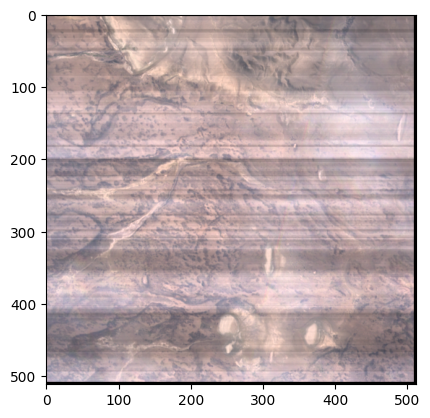

In [15]:
plt.imshow(img)

In [1]:
import torch

In [3]:
sa = set(torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth', map_location='cpu').get('state_dict', {}))
sb = set(torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/001_dinov3lightning_vit-l_chinasiweidataset_load_from_sat493m_pretrain/checkpoints/model_epoch_epoch=31_step_step=145000_loss_total_loss=12.187500.ckpt', map_location='cpu').get('state_dict', {}))

In [2]:
pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth', map_location='cpu')

sa = set(pretrain)
sa

{'blocks.0.attn.proj.bias',
 'blocks.0.attn.proj.weight',
 'blocks.0.attn.qkv.bias',
 'blocks.0.attn.qkv.bias_mask',
 'blocks.0.attn.qkv.weight',
 'blocks.0.ls1.gamma',
 'blocks.0.ls2.gamma',
 'blocks.0.mlp.fc1.bias',
 'blocks.0.mlp.fc1.weight',
 'blocks.0.mlp.fc2.bias',
 'blocks.0.mlp.fc2.weight',
 'blocks.0.norm1.bias',
 'blocks.0.norm1.weight',
 'blocks.0.norm2.bias',
 'blocks.0.norm2.weight',
 'blocks.1.attn.proj.bias',
 'blocks.1.attn.proj.weight',
 'blocks.1.attn.qkv.bias',
 'blocks.1.attn.qkv.bias_mask',
 'blocks.1.attn.qkv.weight',
 'blocks.1.ls1.gamma',
 'blocks.1.ls2.gamma',
 'blocks.1.mlp.fc1.bias',
 'blocks.1.mlp.fc1.weight',
 'blocks.1.mlp.fc2.bias',
 'blocks.1.mlp.fc2.weight',
 'blocks.1.norm1.bias',
 'blocks.1.norm1.weight',
 'blocks.1.norm2.bias',
 'blocks.1.norm2.weight',
 'blocks.10.attn.proj.bias',
 'blocks.10.attn.proj.weight',
 'blocks.10.attn.qkv.bias',
 'blocks.10.attn.qkv.bias_mask',
 'blocks.10.attn.qkv.weight',
 'blocks.10.ls1.gamma',
 'blocks.10.ls2.gamma',
 

In [3]:
pretrain.keys()


odict_keys(['cls_token', 'storage_tokens', 'mask_token', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'rope_embed.periods', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.qkv.bias_mask', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.qkv.bias_mask', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.ls1.gamma', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.fc1.weight', 'blocks.1.mlp.fc1.bias', 'blocks.1.mlp.fc2.weight', 'blocks.1.mlp.fc2.bias', 'blocks.1.ls2.gamma', 'blocks.2.norm1.weight', 'blocks.2.norm1.bias', 'blocks.2.attn.qkv.weight', 'blocks.2.attn.qkv.bias

In [2]:
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/work_dirs/dinov3_vit-l_load_pretrain_debug/eval/training_124999/teacher_checkpoint.pth', map_location='cpu')['teacher']
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/001_dinov3lightning_vit-l_chinasiweidataset_load_from_sat493m_pretrain/final_ssl_model.pth', map_location='cpu')
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/001_dinov3lightning_vit-l_chinasiweidataset_load_from_sat493m_pretrain/final_model.ckpt', map_location='cpu')

# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/002_dinov3lightning_vit-l_chinasiweidataset_all_bands_20251023_load_from_sat493m_pretrain/final_ssl_model.pth', map_location='cpu')
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/work_dirs/003_dinov3_vit-l_20251117_all_bands_datset_with_downstream_task_data_150w/eval/training_124999/teacher_checkpoint.pth', map_location='cpu')['teacher']
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/005_dinov3lightning_vit-l_chinasiweidataset_all_bands_20251117_add_downstream_dataset_load_from_sat493m_pretrain_lr_1e-4/final_ssl_model.pth', map_location='cpu')
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/DinoV3LightningTraining/output/006_dinov3lightning_vit-l_FIX_CONFIG_chinasiwei_20251117_add_downstream_dataset_load_from_sat493m_pretrain_lr_1e-4/final_ssl_model.pth', map_location='cpu')
# my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/work_dirs/101_multidistillation_test/vits/eval/training_24999/teacher_checkpoint.pth', map_location='cpu')['teacher']
my_pretrain = torch.load('/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/work_dirs/005_channel_adaptive_dinov3_vit-l_20251226_all_bands_datset_with_downstream_task_data/eval/training_374999/teacher_checkpoint.pth', map_location='cpu')['teacher']



In [3]:

sb = set(my_pretrain)
sb

{'backbone.blocks.0.attn.proj.bias',
 'backbone.blocks.0.attn.proj.weight',
 'backbone.blocks.0.attn.qkv.bias',
 'backbone.blocks.0.attn.qkv.bias_mask',
 'backbone.blocks.0.attn.qkv.weight',
 'backbone.blocks.0.ls1.gamma',
 'backbone.blocks.0.ls2.gamma',
 'backbone.blocks.0.mlp.fc1.bias',
 'backbone.blocks.0.mlp.fc1.weight',
 'backbone.blocks.0.mlp.fc2.bias',
 'backbone.blocks.0.mlp.fc2.weight',
 'backbone.blocks.0.norm1.bias',
 'backbone.blocks.0.norm1.weight',
 'backbone.blocks.0.norm2.bias',
 'backbone.blocks.0.norm2.weight',
 'backbone.blocks.1.attn.proj.bias',
 'backbone.blocks.1.attn.proj.weight',
 'backbone.blocks.1.attn.qkv.bias',
 'backbone.blocks.1.attn.qkv.bias_mask',
 'backbone.blocks.1.attn.qkv.weight',
 'backbone.blocks.1.ls1.gamma',
 'backbone.blocks.1.ls2.gamma',
 'backbone.blocks.1.mlp.fc1.bias',
 'backbone.blocks.1.mlp.fc1.weight',
 'backbone.blocks.1.mlp.fc2.bias',
 'backbone.blocks.1.mlp.fc2.weight',
 'backbone.blocks.1.norm1.bias',
 'backbone.blocks.1.norm1.weight'

In [4]:
prefix = 'backbone.'
# prefix = 'teacher.backbone._orig_mod.'
filtered = {k[len(prefix):]: v for k, v in my_pretrain.items() if isinstance(k, str) and k.startswith(prefix)}

In [5]:
filtered

{'cls_token': tensor([[[-0.0170, -0.0014, -0.0025,  ..., -0.0021, -0.0005,  0.0030]]]),
 'storage_tokens': tensor([[[ 0.0008,  0.0052,  0.0113,  ...,  0.0086, -0.0105,  0.0020],
          [ 0.0165,  0.0220, -0.0034,  ..., -0.0232,  0.0037,  0.0161],
          [-0.0184, -0.0073, -0.0043,  ...,  0.0014,  0.0014,  0.0063],
          [-0.0041, -0.0070,  0.0014,  ...,  0.0086, -0.0039,  0.0094]]]),
 'mask_token': tensor([[-0.0199, -0.0340, -0.0054,  ..., -0.0048, -0.0006, -0.0029]]),
 'patch_embed.proj.weight': tensor([[[[ 1.0332e-02, -1.1507e-02,  2.4259e-02,  ...,  3.9062e-03,
            -2.9721e-02, -4.7906e-03],
           [-1.5651e-02, -2.8619e-02,  9.4652e-03,  ...,  1.8761e-02,
             1.3621e-02,  4.3735e-02],
           [ 2.5039e-02, -1.8283e-02,  3.8156e-03,  ...,  7.4765e-03,
            -4.7104e-03, -1.6979e-02],
           ...,
           [-4.5308e-03,  1.6987e-02,  1.7852e-02,  ..., -6.9273e-03,
             3.7224e-02, -7.3296e-03],
           [-2.8921e-02, -9.9915e-03,

In [6]:
sb = set(filtered)
sb

{'blocks.0.attn.proj.bias',
 'blocks.0.attn.proj.weight',
 'blocks.0.attn.qkv.bias',
 'blocks.0.attn.qkv.bias_mask',
 'blocks.0.attn.qkv.weight',
 'blocks.0.ls1.gamma',
 'blocks.0.ls2.gamma',
 'blocks.0.mlp.fc1.bias',
 'blocks.0.mlp.fc1.weight',
 'blocks.0.mlp.fc2.bias',
 'blocks.0.mlp.fc2.weight',
 'blocks.0.norm1.bias',
 'blocks.0.norm1.weight',
 'blocks.0.norm2.bias',
 'blocks.0.norm2.weight',
 'blocks.1.attn.proj.bias',
 'blocks.1.attn.proj.weight',
 'blocks.1.attn.qkv.bias',
 'blocks.1.attn.qkv.bias_mask',
 'blocks.1.attn.qkv.weight',
 'blocks.1.ls1.gamma',
 'blocks.1.ls2.gamma',
 'blocks.1.mlp.fc1.bias',
 'blocks.1.mlp.fc1.weight',
 'blocks.1.mlp.fc2.bias',
 'blocks.1.mlp.fc2.weight',
 'blocks.1.norm1.bias',
 'blocks.1.norm1.weight',
 'blocks.1.norm2.bias',
 'blocks.1.norm2.weight',
 'blocks.10.attn.proj.bias',
 'blocks.10.attn.proj.weight',
 'blocks.10.attn.qkv.bias',
 'blocks.10.attn.qkv.bias_mask',
 'blocks.10.attn.qkv.weight',
 'blocks.10.ls1.gamma',
 'blocks.10.ls2.gamma',
 

In [8]:
sa - sb, sb - sa

(set(), set())

In [13]:
filtered.dtype

AttributeError: 'dict' object has no attribute 'dtype'

In [7]:
torch.save(dict(filtered), "/mnt/mty/open_source_mm/chinasiwei_fm/dinov3-main/work_dirs/005_channel_adaptive_dinov3_vit-l_20251226_all_bands_datset_with_downstream_task_data/eval/training_374999/005_teacher_checkpoint-08c60483.pth")

# Potsdam process


In [1]:
# /mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam
ids_train = "2_10 3_10 3_11 3_12 4_11 4_12 5_10 5_12 6_8 6_9 6_10 6_11 6_12 7_7 7_9 7_11 7_12".split()
ids_val   = "2_11 2_12 4_10 5_11 6_7 7_8 7_10".split()

import os, glob, re
img_dir = "/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/2_Ortho_RGB"
def write_split(ids, out_txt):
    with open(out_txt, "w") as f:
        for iid in ids:
            # 按你用的通道命名改后缀：RGB / IRRG / RGBIR
            pat = os.path.join(img_dir, f"top_potsdam_{iid}_*.tif")
            files = sorted(glob.glob(pat))
            assert files, f"missing tile {iid}"
            f.write(os.path.basename(files[0]) + "\n")

write_split(ids_train, "/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/train.txt")
write_split(ids_val,   "/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/val.txt")

# test = 全部38减去上述24
all_ids = {re.search(r'top_potsdam_(\d+_\d+)_', p).group(1) for p in glob.glob(os.path.join(img_dir, "top_potsdam_*_*.tif"))}
ids_test = sorted(all_ids - set(ids_train) - set(ids_val))
with open("/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/test.txt","w") as f:
    for iid in ids_test:
        pat = os.path.join(img_dir, f"top_potsdam_{iid}_*.tif")
        f.write(os.path.basename(sorted(glob.glob(pat))[0]) + "\n")


In [12]:
import os, re, math, argparse, glob
import numpy as np
import rasterio as rio
from rasterio.windows import Window
from concurrent.futures import ProcessPoolExecutor, as_completed

# -------------------- 配置：官方常用划分 --------------------
IDS_TRAIN = "2_10 3_10 3_11 3_12 4_11 4_12 5_10 5_12 6_8 6_9 6_10 6_11 6_12 7_7 7_9 7_11 7_12".split()
IDS_VAL   = "2_11 2_12 4_10 5_11 6_7 7_8 7_10".split()
# 测试集 = 全部 38 减去上面 24

# Potsdam 彩色标签 → 类别 ID（0..5）；未知设为 255（ignore）
POTSDAM_COL2ID = {
    (255,255,255): 0,  # impervious
    (  0,  0,255): 1,  # building
    (  0,255,255): 2,  # low veg
    (  0,255,  0): 3,  # tree
    (255,255,  0): 4,  # car
    (255,  0,  0): 5,  # clutter/background
}

# -------------------- 实用函数 --------------------
def infer_image_dir(root, channels):
    # 映射通道名到官方目录名
    m = {
        "RGB":   ("2_Ortho_RGB",    "*_RGB.tif"),
        "IRRG":  ("3_Ortho_IRRG",   "*_IRRG.tif"),
        "RGBIR": ("4_Ortho_RGBIR",  "*_RGBIR.tif"),
    }
    if channels:
        sub, pat = m[channels]
        img_dir = os.path.join(root, sub)
        if not os.path.isdir(img_dir):
            raise FileNotFoundError(f"Not found: {img_dir}")
        return img_dir, pat
    # 自动探测（优先 RGBIR, 其次 RGB, IRRG）
    for ch in ("RGBIR","RGB","IRRG"):
        sub, pat = m[ch]
        d = os.path.join(root, sub)
        if os.path.isdir(d) and glob.glob(os.path.join(d, "top_potsdam_*", pat)) or glob.glob(os.path.join(d, pat)):
            return d, pat
    raise RuntimeError("无法自动识别图像目录，请用 --channels 指定 RGB/IRRG/RGBIR")

def find_label_dir(root):
    d = '1label_coord'
    p = os.path.join(root, d)
    if os.path.isdir(p):
        return p
    raise FileNotFoundError("未找到标签目录（5_Labels_all 或 6_Labels_for_participants）")

def iter_image_label_pairs(img_dir, img_pat, lbl_dir):
    # 支持两种组织：平铺 or 每块一个子目录
    candidates = glob.glob(os.path.join(img_dir, "top_potsdam_*", img_pat)) + \
                 glob.glob(os.path.join(img_dir, img_pat))
    pairs = []
    for ip in sorted(candidates):
        base = os.path.basename(ip)
        m = re.search(r"(top_potsdam_(\d+_\d+))_", base)
        if not m: 
            continue
        stem, tid = m.group(1), m.group(2)
        # 常见的标签名：top_potsdam_<id>_label.tif
        lp = os.path.join(lbl_dir, f"{stem}_label_coords.tif")
        if not os.path.isfile(lp):
            # 兼容老命名（极少数镜像）：*_label.tiff
            alt = lp + "f"
            if os.path.isfile(alt): lp = alt
        if not os.path.isfile(lp):
            print(f"[warn] missing label for {ip}")
            continue
        pairs.append((tid, stem, ip, lp))
    return pairs

def rgb_label_to_id(label_rgb):
    # label_rgb: (3,h,w) uint8
    R, G, B = label_rgb[0], label_rgb[1], label_rgb[2]
    h, w = R.shape
    lab_id = np.full((h, w), 255, np.uint8)
    for (cr, cg, cb), cid in POTSDAM_COL2ID.items():
        m = (R==cr) & (G==cg) & (B==cb)
        lab_id[m] = cid
    return lab_id

def chip_one(stem, img_path, lbl_path, out_img_dir, out_lbl_dir,
             tile, stride, cover_all, skip_blank, compress):
    made = []
    with rio.open(img_path) as rds, rio.open(lbl_path) as lds:
        assert rds.width == lds.width and rds.height == lds.height, f"size mismatch: {stem}"
        H, W = rds.height, rds.width
        lbl_is_rgb = (lds.count == 3)

        # 步数
        y_steps = math.ceil((H - tile) / stride) + 1 if cover_all else max(1, (H - tile) // stride + 1)
        x_steps = math.ceil((W - tile) / stride) + 1 if cover_all else max(1, (W - tile) // stride + 1)

        for iy in range(y_steps):
            y = iy * stride
            if y + tile > H:
                if not cover_all: break
                y = max(0, H - tile)
            for ix in range(x_steps):
                x = ix * stride
                if x + tile > W:
                    if not cover_all: break
                    x = max(0, W - tile)

                win = Window(x, y, min(tile, W - x), min(tile, H - y))
                h, w = int(win.height), int(win.width)

                # 读前三通道（RGB / RGBIR 的前 3 个）
                rgb = rds.read(indexes=[1,2,3], window=win)            # (3,h,w)
                # 读 label
                if lbl_is_rgb:
                    lab_rgb = lds.read(indexes=[1,2,3], window=win)
                    lab_id  = rgb_label_to_id(lab_rgb)
                else:
                    arr = lds.read(1, window=win)
                    nod = lds.nodata
                    lab_id = np.where(arr==nod, 255, arr).astype(np.uint8) if nod is not None else arr.astype(np.uint8, copy=False)

                if skip_blank > 0:
                    valid_ratio = (lab_id != 255).mean()
                    if valid_ratio < skip_blank:
                        continue

                # 写 image
                out_img = os.path.join(out_img_dir, f"{stem}_y{y:05d}_x{x:05d}.tif")
                meta_img = rds.meta.copy()
                meta_img.update(width=w, height=h, count=3, transform=rds.window_transform(win))
                if compress: meta_img["compress"] = compress
                with rio.open(out_img, "w", **meta_img) as dst:
                    dst.write(rgb)

                # 写 label
                out_lbl = os.path.join(out_lbl_dir, f"{stem}_y{y:05d}_x{x:05d}_label.tif")
                meta_lbl = lds.meta.copy()
                meta_lbl.update(width=w, height=h, count=1, dtype="uint8", transform=lds.window_transform(win), nodata=255)
                if compress: meta_lbl["compress"] = compress
                with rio.open(out_lbl, "w", **meta_lbl) as dst:
                    dst.write(lab_id, 1)

                made.append((os.path.basename(out_img), os.path.basename(out_lbl)))
    return made


In [14]:
# Copyright (c) OpenMMLab. All rights reserved.
import argparse
import glob
import math
import os
import os.path as osp
import tempfile
import zipfile

import mmcv
import numpy as np
from mmengine.utils import ProgressBar, mkdir_or_exist


In [24]:


def clip_big_image(image_path, clip_save_dir, clip_size, stride_size, to_label=False):
    # Original image of Potsdam dataset is very large, thus pre-processing
    # of them is adopted. Given fixed clip size and stride size to generate
    # clipped image, the intersection　of width and height is determined.
    # For example, given one 5120 x 5120 original image, the clip size is
    # 512 and stride size is 256, thus it would generate 20x20 = 400 images
    # whose size are all 512x512.
    image = mmcv.imread(image_path)

    h, w, c = image.shape
    clip_size = clip_size
    stride_size = stride_size

    num_rows = math.ceil((h - clip_size) / stride_size) if math.ceil(
        (h - clip_size) /
        stride_size) * stride_size + clip_size >= h else math.ceil(
            (h - clip_size) / stride_size) + 1
    num_cols = math.ceil((w - clip_size) / stride_size) if math.ceil(
        (w - clip_size) /
        stride_size) * stride_size + clip_size >= w else math.ceil(
            (w - clip_size) / stride_size) + 1

    x, y = np.meshgrid(np.arange(num_cols + 1), np.arange(num_rows + 1))
    xmin = x * clip_size
    ymin = y * clip_size

    xmin = xmin.ravel()
    ymin = ymin.ravel()
    xmin_offset = np.where(xmin + clip_size > w, w - xmin - clip_size,
                           np.zeros_like(xmin))
    ymin_offset = np.where(ymin + clip_size > h, h - ymin - clip_size,
                           np.zeros_like(ymin))
    boxes = np.stack([
        xmin + xmin_offset, ymin + ymin_offset,
        np.minimum(xmin + clip_size, w),
        np.minimum(ymin + clip_size, h)
    ],
                     axis=1)

    if to_label:
        color_map = np.array([[0, 0, 0], [255, 255, 255], [255, 0, 0],
                              [255, 255, 0], [0, 255, 0], [0, 255, 255],
                              [0, 0, 255]])
        flatten_v = np.matmul(
            image.reshape(-1, c),
            np.array([2, 3, 4]).reshape(3, 1))
        out = np.zeros_like(flatten_v)
        for idx, class_color in enumerate(color_map):
            value_idx = np.matmul(class_color,
                                  np.array([2, 3, 4]).reshape(3, 1))
            out[flatten_v == value_idx] = idx
        image = out.reshape(h, w)

    for box in boxes:
        start_x, start_y, end_x, end_y = box
        clipped_image = image[start_y:end_y,
                              start_x:end_x] if to_label else image[
                                  start_y:end_y, start_x:end_x, :]
        idx_i, idx_j = osp.basename(image_path).split('_')[2:4]
        mmcv.imwrite(
            clipped_image.astype(np.uint8),
            osp.join(
                clip_save_dir,
                f'{idx_i}_{idx_j}_{start_x}_{start_y}_{end_x}_{end_y}.png'))

   

In [37]:
dataset_path = '/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/Origin'
tmp_dir = '/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam'
out_dir = '/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/Clip_new_test'
clip_size = 512
stride_size = 512


In [38]:
splits = {
    'train': [
        '2_10', '2_11', '2_12', '3_10', '3_11', '3_12', '4_10', '4_11',
        '4_12', '5_10', '5_11', '5_12', '6_10', '6_11', '6_12', '6_7',
        '6_8', '6_9', '7_10', '7_11', '7_12', '7_7', '7_8', '7_9'
    ],
    'val': [
        '5_15', '6_15', '6_13', '3_13', '4_14', '6_14', '5_14', '2_13',
        '4_15', '2_14', '5_13', '4_13', '3_14', '7_13'
    ]
}


out_dir = out_dir

print('Making directories...')
mkdir_or_exist(osp.join(out_dir, 'img_dir', 'train'))
mkdir_or_exist(osp.join(out_dir, 'img_dir', 'val'))
mkdir_or_exist(osp.join(out_dir, 'ann_dir', 'train'))
mkdir_or_exist(osp.join(out_dir, 'ann_dir', 'val'))

zipp_list = glob.glob(os.path.join(dataset_path, '*y.zip'))
print('Find the data', zipp_list)

for zipp in zipp_list:
    with tempfile.TemporaryDirectory(dir=tmp_dir) as tmp_dir:
        zip_file = zipfile.ZipFile(zipp)
        zip_file.extractall(tmp_dir)
        src_path_list = glob.glob(os.path.join(tmp_dir, '*.tif'))
        if not len(src_path_list):
            sub_tmp_dir = os.path.join(tmp_dir, os.listdir(tmp_dir)[0])
            src_path_list = glob.glob(os.path.join(sub_tmp_dir, '*.tif'))

        prog_bar = ProgressBar(len(src_path_list))
        for i, src_path in enumerate(src_path_list):
            idx_i, idx_j = osp.basename(src_path).split('_')[2:4]
            data_type = 'train' if f'{idx_i}_{idx_j}' in splits[
                'train'] else 'val'
            if 'label' in src_path:
                dst_dir = osp.join(out_dir, 'ann_dir', data_type)
                clip_big_image(src_path, dst_dir, clip_size, stride_size, to_label=True)
            else:
                dst_dir = osp.join(out_dir, 'img_dir', data_type)
                clip_big_image(src_path, dst_dir, clip_size, stride_size, to_label=False)
            prog_bar.update()

    print('Removing the temporary files...')

print('Done!')


Making directories...
Find the data ['/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/Origin/5_Labels_all_noBoundary.zip']
[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 38/38, 0.4 task/s, elapsed: 98s, ETA:     0sRemoving the temporary files...
Done!


In [39]:
from argparse import ArgumentParser

from mmseg.apis import RSImage, RSInferencer

image = "/mnt/SampleDatasets/Segmentation/DataOpen/multi/Potsdam/Origin/2_Ortho_RGB/top_potsdam_2_14_RGB.tif"
config = '/mnt/mty/open_source_mm/chinasiwei_fm/configs/dinov3/dinov3_vit-l_1xb16-160k_potsdam-512x512.py'
checkpoint = '/mnt/mty/open_source_mm/mmsegmentation/work_dirs/dinov3/005_dinov3_vit-l_potsdam_load_from_sat493m_pretrain/best_aAcc_iter_72000.pth'
window_size = (512, 512)
stride = (256, 256)
device = 'cuda:0'
thread = 1
batch_size = 1
output_path = '/mnt/mty/open_source_mm/mmsegmentation/work_dirs/dinov3/005_dinov3_vit-l_potsdam_load_from_sat493m_pretrain/test.tif'


[2025-10-31 09:42:54,440] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/tmp/tmp1fnyk3xt/test.o: In function `main':
test.c:(.text.startup+0x5): undefined reference to `io_pgetevents'
collect2: error: ld returned 1 exit status


 [WARNING]  async_io requires the dev libaio .so object and headers but these were not found.
 [WARNING]  If libaio is already installed (perhaps from source), try setting the CFLAGS and LDFLAGS environment variables to where it can be found.
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  sparse_attn requires a torch version >= 1.5 and < 2.0 but detected 2.3
 [WARNING]  using untested triton version (2.3.1), only 1.0.0 is known to be compatible


ERROR:albumentations.check_version:Error fetching version info
Traceback (most recent call last):
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/urllib/request.py", line 1348, in do_open
    h.request(req.get_method(), req.selector, req.data, headers,
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client.py", line 1298, in request
    self._send_request(method, url, body, headers, encode_chunked)
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client.py", line 1344, in _send_request
    self.endheaders(body, encode_chunked=encode_chunked)
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client.py", line 1293, in endheaders
    self._send_output(message_body, encode_chunked=encode_chunked)
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client.py", line 1052, in _send_output
    self.send(msg)
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client.py", line 990, in send
    self.connect()
  File "/mnt/anaconda3/envs/fm_env/lib/python3.11/http/client

In [41]:

inferencer = RSInferencer.from_config_path(
    config,
    checkpoint,
    batch_size=batch_size,
    thread=thread,
    device=device)
image = RSImage(image)

inferencer.run(image, window_size, stride, output_path)


INFO:dinov3:using base=100 for rope new
INFO:dinov3:using min_period=None for rope new
INFO:dinov3:using max_period=None for rope new
INFO:dinov3:using normalize_coords=separate for rope new
INFO:dinov3:using shift_coords=None for rope new
INFO:dinov3:using rescale_coords=2 for rope new
INFO:dinov3:using jitter_coords=None for rope new
INFO:dinov3:using dtype=fp32 for rope new
INFO:dinov3:using mlp layer as FFN


Loads checkpoint by local backend from path: /mnt/mty/open_source_mm/mmsegmentation/work_dirs/dinov3/005_dinov3_vit-l_potsdam_load_from_sat493m_pretrain/best_aAcc_iter_72000.pth


/mnt/anaconda3/envs/fm_env/lib/python3.11/site-packages/osgeo/gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [ ]:
for tile in ['5_15', '6_15', '6_13', '3_13', '4_14', '6_14', '5_14', '2_13', '4_15', '2_14', '5_13', '4_13', '3_14', '7_13']:
    print(f"processing tile: {tile}")
    

In [60]:
nums = [4,5,6,0,1,2,3]
# nums = [4,5,6,7,0,1,2,3]
target = 0

left = 0
right = len(nums) - 1

while left < right:
    if nums[left] > nums[right]:
        left += 1
        right -= 1
# left, right


if target >= nums[0] and target <= nums[left - 1]:
    pass
elif target >= nums[left] and target <= nums[-1]:
    pass
else return -1


(3, 3)

In [21]:

import numpy as np

def build_channel_first_index(image_paths, n_bands):
    image_paths = np.asarray(image_paths, dtype=object)
    n_bands = np.asarray(n_bands, dtype=np.int64)
    maxC = int(n_bands.max()) if len(n_bands) else 0

    img_ids_list = []
    band_list = []

    # 只循环 maxC 次（通常很小）
    for b in range(maxC):
        ids = np.flatnonzero(n_bands > b)              # 所有有第 b 个band的图片
        img_ids_list.append(ids)
        band_list.append(np.full(ids.shape[0], b, dtype=np.int16))

    img_ids = np.concatenate(img_ids_list) if img_ids_list else np.empty(0, np.int64)
    bands = np.concatenate(band_list) if band_list else np.empty(0, np.int16)

    # 如果你真的需要“展开后的 paths”
    expanded_paths = image_paths[img_ids]
    return expanded_paths.tolist(), np.expand_dims(bands, 1).tolist()

In [22]:
image_paths = ['image1', 'image2', 'image3', 'image4' ]
n_bands = [3, 4, 8, 1]

build_channel_first_index(image_paths, n_bands)

(['image1',
  'image2',
  'image3',
  'image4',
  'image1',
  'image2',
  'image3',
  'image1',
  'image2',
  'image3',
  'image2',
  'image3',
  'image3',
  'image3',
  'image3',
  'image3'],
 [[0],
  [0],
  [0],
  [0],
  [1],
  [1],
  [1],
  [2],
  [2],
  [2],
  [3],
  [3],
  [4],
  [5],
  [6],
  [7]])

In [24]:
full = '/mnt/mty/FM_DATA/512x512/20251011-Basic-SVN10304_crop_512/40_Cropland/SVN1-03_20251004_0000043683_L4D0000046960_RGB_36.30_51.30_tile_27_19_x512_y512.tiff'
with open(full, "rb") as f:
    image_data = f.read()

channels = [2]
image_data = image_data + bytes(channels) + (len(channels)).to_bytes(1, byteorder="big")

In [28]:
import tifffile
from io import BytesIO


In [29]:
numpy_array = tifffile.imread(BytesIO(image_data))

In [30]:
numpy_array.shape

(512, 512, 3)

In [35]:
torch.Tensor(numpy_array).permute(2, 0, 1)[[2]]

torch.Size([512, 1, 512])

In [1]:
full = '/mnt/mty/FM_DATA/512x512/20251021_Value_PAN_MUX_crop_512/PAN/100_MossAndLichen/GF7_DLC_E73.7_N37.4_20250901_L4A0002087230-BWDPAN_73.70_37.40_tile_7_1_x512_y512.tiff'
with open(full, "rb") as f:
    image_data = f.read()
    channels = [0]
    image_data = image_data + bytes(channels) + (len(channels)).to_bytes(1, byteorder="big")


In [3]:
import rasterio as rio
from rasterio.errors import NotGeoreferencedWarning
import warnings
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)
import numpy as np


In [4]:
L = image_data[-1]
_channel = list(image_data[-1 - L: -1])
_image_data = image_data[:-1 - L]


with rio.MemoryFile(_image_data) as mem:
    with mem.open() as src:
        arr = src.read(out_dtype="float32")  # C,H,W
arr.shape

(1, 512, 512)

In [7]:
arr = arr.astype(np.float32)
arr

array([[[157., 151., 156., ..., 158., 151., 154.],
        [158., 157., 152., ..., 156., 155., 161.],
        [156., 146., 149., ..., 157., 157., 160.],
        ...,
        [150., 153., 161., ..., 159., 157., 157.],
        [159., 155., 162., ..., 156., 158., 162.],
        [152., 153., 155., ..., 167., 161., 161.]]], dtype=float32)

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

root_dir = r"/mnt/CLOUD/data/cloudsen12/20260107_all_cloud_and_no_cloud"   # 改成你的目录
overwrite = True              # True: 覆盖原图；False: 另存到 out_dir
out_dir = r"/mnt/CLOUD/data/cloudsen12/20260107_all_cloud_and_no_cloud"    # overwrite=False 时才用

if not overwrite:
    os.makedirs(out_dir, exist_ok=True)

cloud_paths = []
for r, ds, fs in os.walk(root_dir):
    for fn in fs:
        if ".png" in fn:
            cloud_paths.append(os.path.join(r, fn))

changed = 0
skipped = 0

for p in tqdm(cloud_paths, desc="Processing Cloud.png"):
    img = cv2.imread(p, cv2.IMREAD_UNCHANGED)
    if img is None:
        skipped += 1
        continue

    # 将像素值 == 128 的改成 1（支持单通道/多通道；多通道则逐通道替换）
    mask = (img == 128)
    if np.any(mask):
        img = img.copy()
        img[mask] = 1
        changed += 1

        if overwrite:
            save_path = p
        else:
            # 保持相对路径输出
            rel = os.path.relpath(p, root_dir)
            save_path = os.path.join(out_dir, rel)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)

        # 确保 dtype 合法
        if img.dtype != np.uint8 and img.dtype != np.uint16:
            img = img.astype(np.uint8)

        ok = cv2.imwrite(save_path, img)
        if not ok:
            print("write failed:", save_path)

print(f"找到 Cloud.png: {len(cloud_paths)}")
print(f"发生修改并写回: {changed}")
print(f"读取失败跳过: {skipped}")

Processing Cloud.png: 100%|██████████| 433/433 [00:36<00:00, 11.96it/s]

找到 Cloud.png: 433
发生修改并写回: 209
读取失败跳过: 0
